In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Đọc dữ liệu ──────────────────────────────────────────────────────────
df = pd.read_csv("D:superstore_final_dataset.csv", encoding="latin-1")
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Year"]  = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.to_period("M")

print(f"✅ Đã tải {len(df):,} dòng dữ liệu ({df['Year'].min()} – {df['Year'].max()})")
df.head(3)

✅ Đã tải 9,800 dòng dữ liệu (2015 – 2018)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Year,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,2017-11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,2017-11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2017,2017-06


In [ ]:
# ── Bảng màu & cấu hình chung ────────────────────────────────────────────
BG    = "#0f1117"
CARD  = "#1a1d27"
TEXT  = "#e2e8f8"
SUB   = "#8b8fa8"
GRID  = "#2e3250"
C1, C2, C3, C4, C5 = "#6c63ff", "#f06292", "#26d0a0", "#fbbf24", "#a78bfa"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": GRID, "axes.labelcolor": SUB,
    "xtick.color": SUB, "ytick.color": SUB,
    "text.color": TEXT, "grid.color": GRID, "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.spines.bottom": False,
})

def fmt_k(x, _):
    if x >= 1_000_000: return f"${x/1e6:.1f}M"
    if x >= 1_000:     return f"${x/1e3:.0f}K"
    return f"${x:.0f}"



### Biểu đồ 1 - Doanh thu theo tháng (2015-2018)

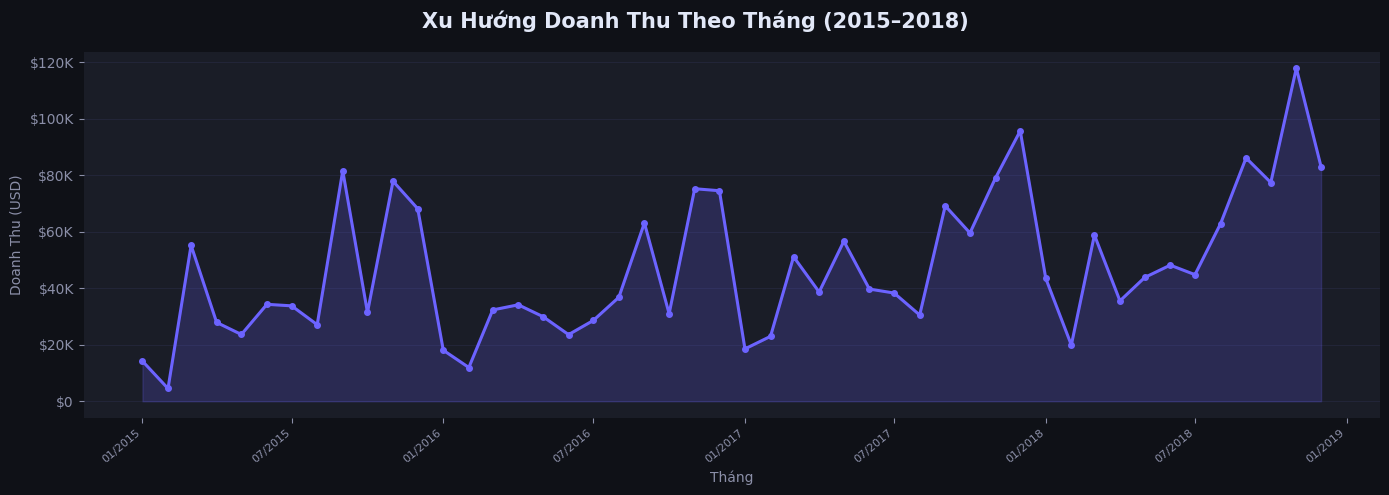

In [9]:
monthly = df.groupby("Month")["Sales"].sum().reset_index()
monthly["Month_dt"] = monthly["Month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Xu Hướng Doanh Thu Theo Tháng (2015–2018)",
             fontsize=15, fontweight="bold", color=TEXT)

ax.fill_between(monthly["Month_dt"], monthly["Sales"], alpha=0.2, color=C1)
ax.plot(monthly["Month_dt"], monthly["Sales"],
        color=C1, linewidth=2.2, marker="o", markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.yaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m/%Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha="right", fontsize=8)
ax.set_xlabel("Tháng"); ax.set_ylabel("Doanh Thu (USD)")

plt.tight_layout()
plt.savefig("D:/01_monthly_trend.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



### Biểu đồ 2 - Doanh thu theo danh mục sản phẩm

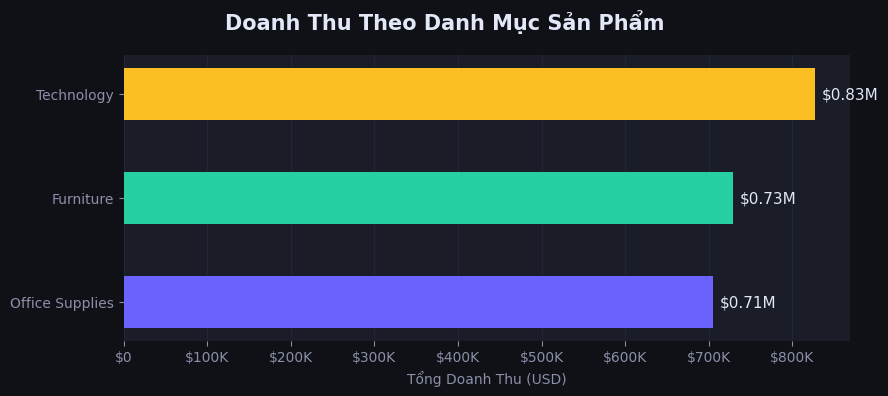

In [ ]:
cat_sales = df.groupby("Category")["Sales"].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Doanh Thu Theo Danh Mục Sản Phẩm",
             fontsize=15, fontweight="bold", color=TEXT)

bars = ax.barh(cat_sales.index, cat_sales.values,
               color=[C1, C3, C4], height=0.5, edgecolor="none")
for bar, val in zip(bars, cat_sales.values):
    ax.text(val + cat_sales.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"${val/1e6:.2f}M", va="center", fontsize=11, color=TEXT)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.xaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
ax.set_xlabel("Tổng Doanh Thu (USD)")

plt.tight_layout()
plt.savefig("D:/02_category_sales.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()



### Biểu đồ 3 – Doanh Thu Theo Khu Vực

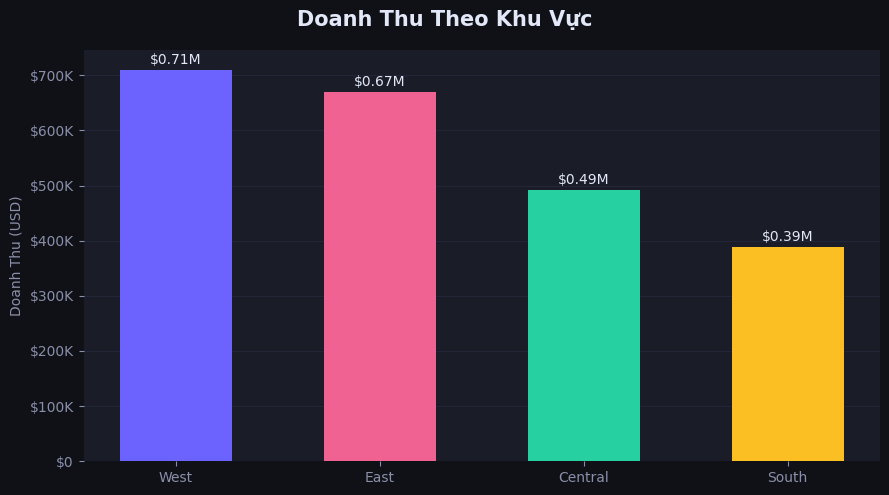

💾 Đã lưu: 03_region_sales.png


In [12]:
reg_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Doanh Thu Theo Khu Vực",
             fontsize=15, fontweight="bold", color=TEXT)

bars = ax.bar(reg_sales.index, reg_sales.values,
              color=[C1, C2, C3, C4], width=0.55, edgecolor="none")
for bar, val in zip(bars, reg_sales.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + reg_sales.max() * 0.015,
            f"${val/1e6:.2f}M", ha="center", fontsize=10, color=TEXT)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.yaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
ax.set_ylabel("Doanh Thu (USD)")

plt.tight_layout()
plt.savefig("D:/03_region_sales.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Đã lưu: 03_region_sales.png")


### Biểu đồ 4 – Doanh Thu Theo Phân Khúc Khách Hàng

In [ ]:
seg_sales = df.groupby("Segment")["Sales"].sum()

fig, ax = plt.subplots(figsize=(7, 7))
fig.suptitle("Doanh Thu Theo Phân Khúc Khách Hàng",
             fontsize=15, fontweight="bold", color=TEXT)

wedges, texts, autotexts = ax.pie(
    seg_sales.values, labels=seg_sales.index,
    colors=[C4, C1, C3], autopct="%1.1f%%",
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor=BG, linewidth=3, width=0.6),
)
for t in texts:     t.set_color(TEXT); t.set_fontsize(12)
for t in autotexts: t.set_color(BG);  t.set_fontsize(10); t.set_fontweight("bold")

plt.tight_layout()
plt.savefig("D:/04_segment_donut.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾 Đã lưu: 04_segment_donut.png")


### Biểu đồ 5 – Doanh Thu Theo Sub-Category

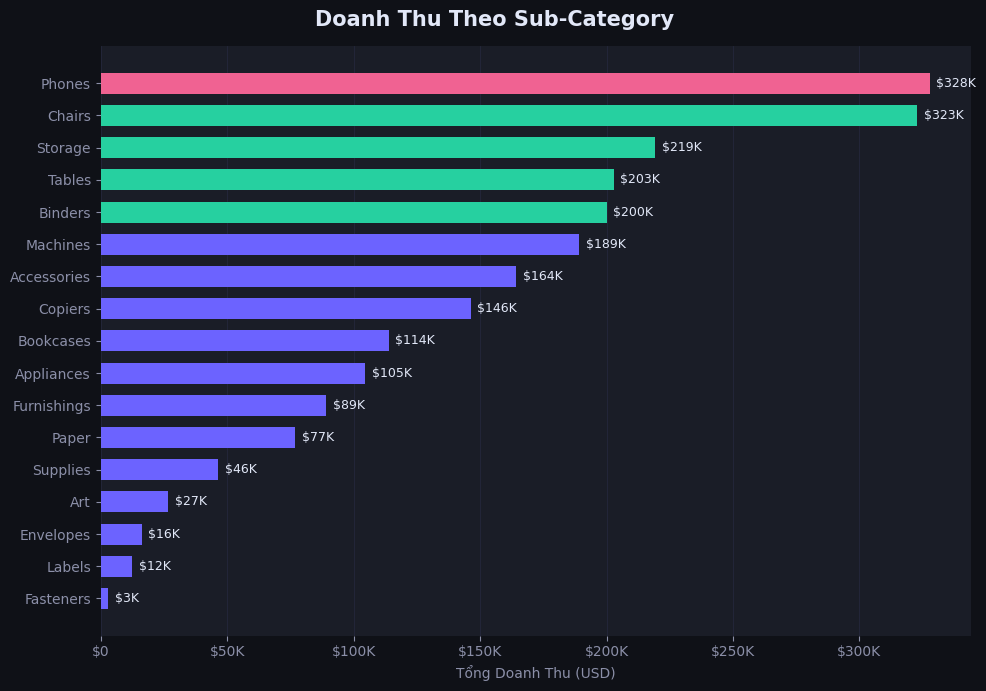

💾 Đã lưu: 05_subcategory_sales.png


In [13]:
sub_sales = df.groupby("Sub_Category")["Sales"].sum().sort_values()

bar_colors = [
    C2 if v == sub_sales.max()
    else (C3 if v >= sub_sales.quantile(0.7) else C1)
    for v in sub_sales.values
]

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Doanh Thu Theo Sub-Category",
             fontsize=15, fontweight="bold", color=TEXT)

bars = ax.barh(sub_sales.index, sub_sales.values,
               color=bar_colors, height=0.65, edgecolor="none")
for bar, val in zip(bars, sub_sales.values):
    ax.text(val + sub_sales.max() * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f"${val/1e3:.0f}K", va="center", fontsize=9, color=TEXT)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.xaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
ax.set_xlabel("Tổng Doanh Thu (USD)")

plt.tight_layout()
plt.savefig("D:/05_subcategory_sales.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾 Đã lưu: 05_subcategory_sales.png")


## Biểu đồ 6 – Phương Thức Vận Chuyển

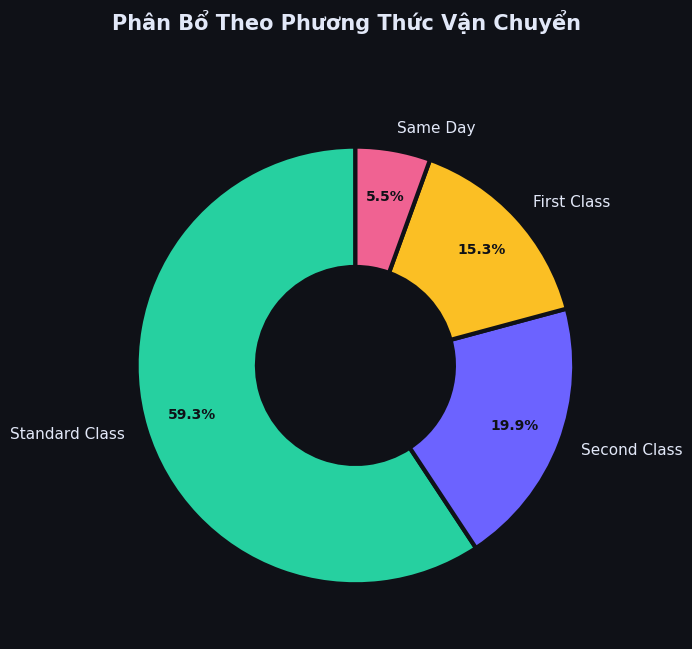

💾 Đã lưu: 06_shipmode_donut.png


In [14]:
ship_sales = df.groupby("Ship_Mode")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
fig.suptitle("Phân Bổ Theo Phương Thức Vận Chuyển",
             fontsize=15, fontweight="bold", color=TEXT)

wedges, texts, autotexts = ax.pie(
    ship_sales.values, labels=ship_sales.index,
    colors=[C3, C1, C4, C2], autopct="%1.1f%%",
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor=BG, linewidth=3, width=0.55),
)
for t in texts:     t.set_color(TEXT); t.set_fontsize(11)
for t in autotexts: t.set_color(BG);  t.set_fontsize(10); t.set_fontweight("bold")

plt.tight_layout()
plt.savefig("06_shipmode_donut.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾 Đã lưu: 06_shipmode_donut.png")


### Biểu đồ 7 – Doanh Thu Theo Năm & Danh Mục

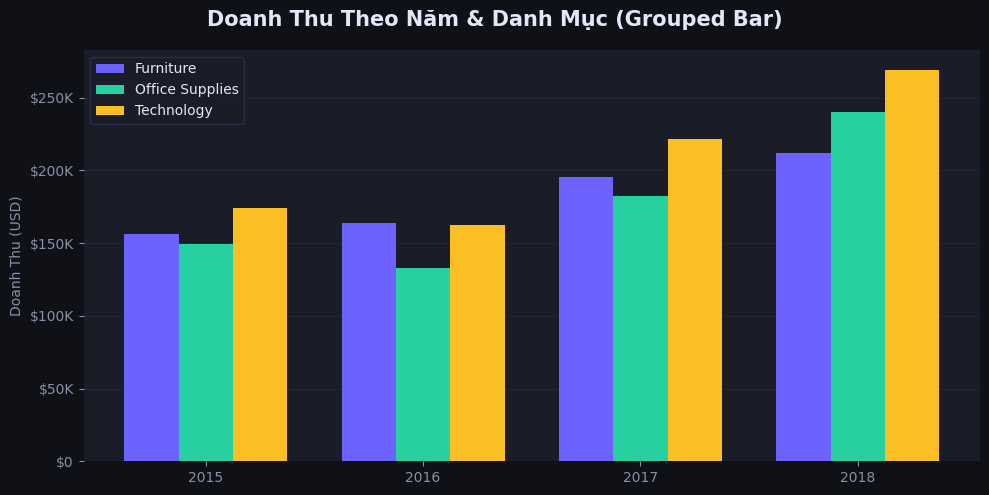

💾 Đã lưu: 07_yearly_category.png


In [15]:
yearly_cat = df.groupby(["Year", "Category"])["Sales"].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Doanh Thu Theo Năm & Danh Mục (Grouped Bar)",
             fontsize=15, fontweight="bold", color=TEXT)

width = 0.25
x     = range(len(yearly_cat))
for i, (cat, col) in enumerate(zip(yearly_cat.columns, [C1, C3, C4])):
    offset = (i - 1) * width
    ax.bar([xi + offset for xi in x], yearly_cat[cat].values,
           width=width, color=col, label=cat, edgecolor="none")

ax.set_xticks(list(x))
ax.set_xticklabels(yearly_cat.index.astype(str))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.yaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
ax.set_ylabel("Doanh Thu (USD)")
ax.legend(fontsize=10, facecolor=CARD, edgecolor=GRID, labelcolor=TEXT, loc="upper left")

plt.tight_layout()
plt.savefig("07_yearly_category.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾 Đã lưu: 07_yearly_category.png")


### Biểu đồ 8 – Top 10 Tiểu Bang Doanh Thu Cao Nhất

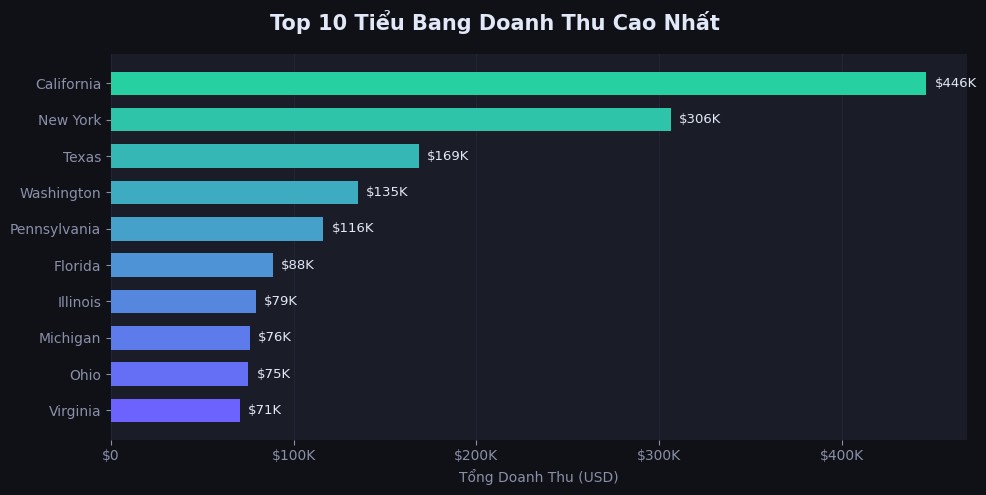

💾 Đã lưu: 08_top10_states.png


In [16]:
top10 = df.groupby("State")["Sales"].sum().nlargest(10).sort_values()
grad_palette = sns.color_palette(f"blend:{C1},{C3}", n_colors=10)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Top 10 Tiểu Bang Doanh Thu Cao Nhất",
             fontsize=15, fontweight="bold", color=TEXT)

bars = ax.barh(top10.index, top10.values,
               color=grad_palette, height=0.65, edgecolor="none")
for bar, val in zip(bars, top10.values):
    ax.text(val + top10.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"${val/1e3:.0f}K", va="center", fontsize=9.5, color=TEXT)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.xaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
ax.set_xlabel("Tổng Doanh Thu (USD)")

plt.tight_layout()
plt.savefig("08_top10_states.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾 Đã lưu: 08_top10_states.png")
